In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
from pathlib import Path

In [ ]:
load_dotenv()
root_dir = Path(os.getenv("ROOT_DIR"))

results_path = root_dir / "results" / "ablation_results_test_v3_best_model.csv"
df = pd.read_csv(results_path)
df

,experiment,fold,val_f1,val_iou,val_precision,val_recall (sensitivity),val_auc,val_specificity,test_f1,test_iou,test_precision,test_recall (sensitivity),test_auc,test_specificity
0,no_transform,0,0.890446,0.802526,0.926048,0.857480,0.922071,0.986661,0.462613,0.300909,0.991659,0.301672,0.650654,0.999635
1,no_transform,1,0.566420,0.395109,0.932634,0.406716,0.700640,0.994565,0.098140,0.051602,0.978453,0.051661,0.525749,0.999837
2,no_transform,2,0.894574,0.809257,0.854120,0.939050,0.951643,0.964236,0.566380,0.395070,0.928305,0.407504,0.701491,0.995479
3,no_transform,3,0.937932,0.883119,0.920831,0.955681,0.968493,0.981305,0.582044,0.410481,0.831106,0.447838,0.717382,0.986926
4,no_transform,4,0.895958,0.811526,0.878581,0.914037,0.944681,0.975325,0.595727,0.424224,0.899755,0.445270,0.719072,0.992873
5,full_transform,0,0.917926,0.848303,0.931647,0.904603,0.945829,0.987055,0.686882,0.523092,0.741218,0.639969,0.803936,0.967903
6,full_transform,1,0.876960,0.780880,0.867951,0.886157,0.931596,0.977035,0.622042,0.451423,0.554661,0.708058,0.813195,0.918332
7,full_transform,2,0.913610,0.840960,0.917721,0.909536,0.946631,0.983726,0.693970,0.531358,0.662631,0.728419,0.837572,0.946724
8,full_transform,3,0.906911,0.829678,0.930347,0.884627,0.935813,0.986998,0.763583,0.617577,0.682696,0.866213,0.904189,0.942165
9,full_transform,4,0.900817,0.819533,0.883413,0.918921,0.947405,0.975889,0.744503,0.592994,0.868206,0.651654,0.818722,0.985790


In [ ]:
grouped = df.groupby('experiment').mean().reset_index()
metric = 'f1'
test_metric = f'test_{metric}'
val_metric = f'val_{metric}'
grouped = grouped.sort_values(by=test_metric, ascending=True)
grouped["delta"] = grouped[val_metric] - grouped[test_metric]
grouped

,experiment,fold,val_f1,val_iou,val_precision,val_recall (sensitivity),val_auc,val_specificity,test_f1,test_iou,test_precision,test_recall (sensitivity),test_auc,test_specificity,delta
0,fotometric_degradation_transform,2.0,0.910376,0.835593,0.899108,0.922416,0.950654,0.978892,0.414141,0.290500,0.760580,0.297610,0.647531,0.997452,0.496235
3,no_transform,2.0,0.837066,0.740307,0.902443,0.814593,0.897506,0.980418,0.460981,0.316457,0.925856,0.330789,0.662869,0.994950,0.376085
1,full_transform,2.0,0.903245,0.823871,0.906216,0.900769,0.941455,0.982141,0.702196,0.543289,0.701883,0.718863,0.835523,0.952183,0.201049
2,geometric_structural_transform,2.0,0.889244,0.801626,0.885239,0.896702,0.935886,0.975071,0.726401,0.571336,0.698054,0.775315,0.861802,0.948289,0.162843


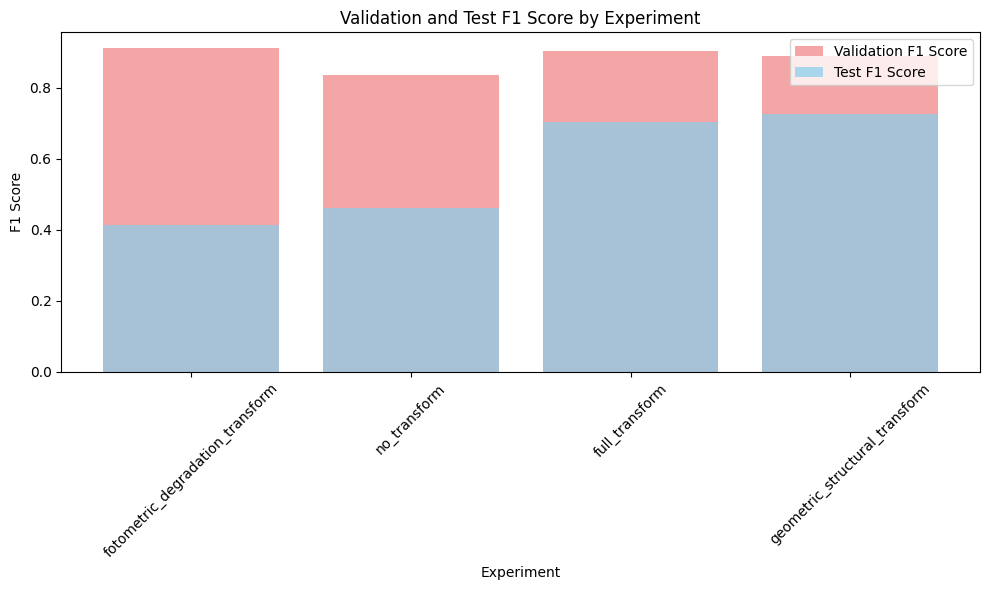

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(grouped['experiment'], grouped[val_metric], color='lightcoral', alpha=0.7, label='Validation F1 Score')
plt.bar(grouped['experiment'], grouped[test_metric], color='skyblue', alpha=0.7, label='Test F1 Score')
plt.xlabel('Experiment')
plt.ylabel('F1 Score')
plt.title('Validation and Test F1 Score by Experiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

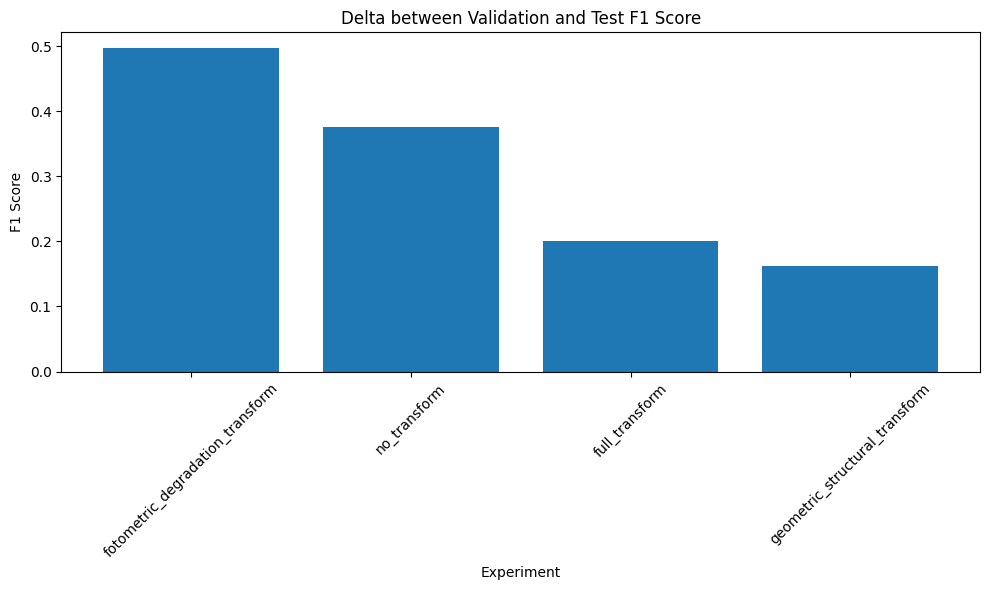

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(grouped['experiment'], grouped["delta"])
plt.xlabel('Experiment')
plt.ylabel('F1 Score')
plt.title('Delta between Validation and Test F1 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()